# 02 · LLM-judge reliability

The unified judge does extraction + verdict. How reliable is it? We compare
independent judge runs per sample — Cohen's κ and raw agreement — which probes
the extraction/scoring stage (𝓔).


In [1]:
import nbtools as nb
from nbtools import show_df, show_fig, show_md, run_mod, heavy, REGEN, REPORTS_DIR
print("SAYF_NB_REGEN =", REGEN, "  (heavy GPU/API steps run only when True)")
print("reports dir  :", REPORTS_DIR)

SAYF_NB_REGEN = False   (heavy GPU/API steps run only when True)
reports dir  : /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports


### 3-judge agreement — `analysis.judge_agreement`

In [2]:
run_mod("judge_agreement", "analysis.judge_agreement")
show_df("judge_agreement/per_cell_default_vs_v1.csv")

Models: 10  Tasks: 23


Wrote /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/judge_agreement/
  per_cell_default_vs_v1.csv    — 198 rows
  per_cell_aggregate_compare.csv — 230 rows
  summary.md
  disagreements/                 — 140 JSONL files
[judge_agreement] recomputed live.


,model,task,n,raw_agreement,kappa,n_disagree,n_def_correct_v1_wrong,n_v1_correct_def_wrong
0,GPT-5.4,ate,55,0.9818,0.7909,1,1,0
1,GPT-5.4,rcm,990,1.0000,1.0000,0,0,0
2,GPT-5.4,vsp,681,0.9956,0.9911,3,0,3
3,GPT-5.4,ckt,2822,1.0000,1.0000,0,0,0
4,GPT-5.4,rms,481,1.0000,1.0000,0,0,0
...,...,...,...,...,...,...,...,...
193,RedSage-Qwen3-8B-DPO,redsage_kali,5000,0.9996,0.9987,2,2,0
194,RedSage-Qwen3-8B-DPO,cybermetric,498,1.0000,1.0000,0,0,0
195,RedSage-Qwen3-8B-DPO,mmlu_cs,100,1.0000,1.0000,0,0,0
196,RedSage-Qwen3-8B-DPO,secbench,646,1.0000,1.0000,0,0,0


,model,task,n,raw_agreement,kappa,n_disagree,n_def_correct_v1_wrong,n_v1_correct_def_wrong
0,GPT-5.4,ate,55,0.9818,0.7909,1,1,0
1,GPT-5.4,rcm,990,1.0000,1.0000,0,0,0
2,GPT-5.4,vsp,681,0.9956,0.9911,3,0,3
3,GPT-5.4,ckt,2822,1.0000,1.0000,0,0,0
4,GPT-5.4,rms,481,1.0000,1.0000,0,0,0
...,...,...,...,...,...,...,...,...
193,RedSage-Qwen3-8B-DPO,redsage_kali,5000,0.9996,0.9987,2,2,0
194,RedSage-Qwen3-8B-DPO,cybermetric,498,1.0000,1.0000,0,0,0
195,RedSage-Qwen3-8B-DPO,mmlu_cs,100,1.0000,1.0000,0,0,0
196,RedSage-Qwen3-8B-DPO,secbench,646,1.0000,1.0000,0,0,0


### Summary (κ averages, per-task/per-model, lowest-κ cells)

In [3]:
show_md("judge_agreement/summary.md")

# Judge-agreement summary

Generated by `analysis/judge_agreement.py`. Three judge tracks:

- **default** — `judge_<MODEL>/eval_results/`
- **v1** — `judge_<MODEL>_v1/eval_results/`
- **v2** — `judge_<MODEL>_v2/eval_results/` (different inference run)

Default and v1 judge the same `responses_<MODEL>/` file so they support per-sample κ. v2 judges `responses_<MODEL>_v2/` (a different inference); we report only its aggregate cell accuracy.

## Overall (default vs v1)

- Cells compared: **198**
- Mean κ: **0.906**  (n=195 non-degenerate)
- Mean raw agreement: **0.966**

## Per-task agreement (default vs v1, averaged across models)

| Task | mean κ | mean raw agreement | models |
|---|---|---|---|
| ate | 0.778 | 0.992 | 9 |
| rcm | 0.985 | 0.994 | 9 |
| vsp | 0.956 | 0.985 | 9 |
| ckt | 0.971 | 0.990 | 9 |
| rms | 0.849 | 0.998 | 9 |
| taa | 0.973 | 0.990 | 9 |
| cti_taa | NA | NA | 0 |
| mcq | 0.989 | 0.995 | 9 |
| athena_ate | 0.271 | 0.679 | 9 |
| athena_rcm | 0.995 | 0.998 | 9 |
| athena_vsp | 0.973 | 0.992 | 9 |
| secure_maet | 0.991 | 0.999 | 9 |
| secure_cwet | 0.990 | 0.998 | 9 |
| secure_kcv | 0.794 | 0.920 | 9 |
| redsage_frameworks | 0.984 | 0.995 | 9 |
| redsage_generals | 0.988 | 0.997 | 9 |
| redsage_skills | 0.982 | 0.997 | 9 |
| redsage_cli | 0.982 | 0.996 | 9 |
| redsage_kali | 0.990 | 0.997 | 9 |
| cybermetric | 0.831 | 0.961 | 9 |
| mmlu_cs | 0.961 | 0.988 | 9 |
| secbench | 0.993 | 0.998 | 9 |
| seceval | 0.676 | 0.782 | 9 |

## Per-model agreement (default vs v1, averaged across tasks)

| Model | mean κ | mean raw agreement | tasks |
|---|---|---|---|
| GPT-5.4 | 0.910 | 0.964 | 22 |
| Llama-3.3-70B-Instruct | 0.896 | 0.956 | 22 |
| Llama-Primus-Nemotron-70B-Instruct | 0.896 | 0.943 | 22 |
| Gemma-4-31B-it | 0.882 | 0.945 | 22 |
| Qwen3.6-35B-A3B | 0.921 | 0.976 | 22 |
| GPT-oss-20B | 0.787 | 0.955 | 22 |
| Foundation-Sec-8B-Instruct | 0.956 | 0.982 | 22 |
| Llama-Primus-Merged | 0.954 | 0.986 | 22 |
| RedSage-Qwen3-8B-DPO | 0.961 | 0.983 | 22 |
| claude-sonnet-4-6-cyberxpert | NA | NA | 0 |

## v2 coverage

v2 contributed to **57** cells across **3** models.

### Top v2 vs (def avg v1) discrepancies (|delta| ≥ 0.05)

| model | task | v2 acc | def/v1 mean | |Δ| |
|---|---|---|---|---|
| Llama-Primus-Nemotron-70B-Instruct | cybermetric | 0.046 | 0.934 | 0.888 |
| Llama-Primus-Nemotron-70B-Instruct | secure_kcv | 0.000 | 0.848 | 0.848 |
| Llama-Primus-Nemotron-70B-Instruct | secure_cwet | 0.094 | 0.940 | 0.845 |
| Foundation-Sec-8B-Instruct | cybermetric | 0.010 | 0.852 | 0.842 |
| Llama-Primus-Nemotron-70B-Instruct | secure_maet | 0.086 | 0.911 | 0.826 |
| Foundation-Sec-8B-Instruct | secure_kcv | 0.015 | 0.805 | 0.790 |
| Llama-Primus-Nemotron-70B-Instruct | rcm | 0.091 | 0.652 | 0.561 |
| Foundation-Sec-8B-Instruct | secure_maet | 0.350 | 0.846 | 0.496 |
| Llama-Primus-Nemotron-70B-Instruct | vsp | 0.111 | 0.546 | 0.435 |
| Foundation-Sec-8B-Instruct | vsp | 0.091 | 0.519 | 0.428 |
| Foundation-Sec-8B-Instruct | secure_cwet | 0.436 | 0.834 | 0.399 |
| Llama-Primus-Nemotron-70B-Instruct | ate | 0.017 | 0.309 | 0.292 |
| Foundation-Sec-8B-Instruct | mcq | 0.278 | 0.563 | 0.284 |
| RedSage-Qwen3-8B-DPO | seceval | 0.467 | 0.742 | 0.275 |
| Llama-Primus-Nemotron-70B-Instruct | seceval | 0.612 | 0.370 | 0.242 |
| RedSage-Qwen3-8B-DPO | vsp | 0.379 | 0.555 | 0.176 |
| RedSage-Qwen3-8B-DPO | secure_kcv | 0.637 | 0.809 | 0.172 |
| RedSage-Qwen3-8B-DPO | cybermetric | 0.742 | 0.902 | 0.160 |
| Llama-Primus-Nemotron-70B-Instruct | secbench | 0.697 | 0.846 | 0.149 |
| Llama-Primus-Nemotron-70B-Instruct | mmlu_cs | 0.870 | 0.735 | 0.135 |

## Cells with weakest default-vs-v1 agreement (lowest κ)

| model | task | κ | raw | n | n_disagree |
|---|---|---|---|---|---|
| GPT-oss-20B | rms | -0.003 | 0.990 | 497 | 5 |
| GPT-oss-20B | ate | 0.000 | 0.964 | 55 | 2 |
| Llama-Primus-Nemotron-70B-Instruct | seceval | 0.006 | 0.282 | 2188 | 1571 |
| GPT-oss-20B | athena_ate | 0.075 | 0.744 | 497 | 127 |
| Llama-3.3-70B-Instruct | seceval | 0.099 | 0.410 | 2188 | 1290 |
| Gemma-4-31B-it | seceval | 0.126 | 0.413 | 2188 | 1285 |
| GPT-5.4 | cybermetric | 0.195 | 0.762 | 499 | 119 |
| Llama-Primus-Nemotron-70B-Instruct | athena_ate | 0.214 | 0.587 | 499 | 206 |
| GPT-oss-20B | secure_kcv | 0.215 | 0.599 | 461 | 185 |
| GPT-5.4 | athena_ate | 0.248 | 0.554 | 498 | 222 |
| Llama-Primus-Merged | athena_ate | 0.269 | 0.738 | 497 | 130 |
| Gemma-4-31B-it | athena_ate | 0.275 | 0.641 | 499 | 179 |
| Qwen3.6-35B-A3B | athena_ate | 0.283 | 0.644 | 497 | 177 |
| Foundation-Sec-8B-Instruct | athena_ate | 0.329 | 0.727 | 498 | 136 |
| RedSage-Qwen3-8B-DPO | athena_ate | 0.374 | 0.683 | 499 | 158 |
| Llama-3.3-70B-Instruct | athena_ate | 0.376 | 0.794 | 499 | 103 |
| Gemma-4-31B-it | secure_kcv | 0.585 | 0.852 | 461 | 68 |
| Llama-3.3-70B-Instruct | cybermetric | 0.626 | 0.930 | 500 | 35 |
| Qwen3.6-35B-A3B | ate | 0.658 | 0.982 | 55 | 1 |
| Llama-3.3-70B-Instruct | secure_kcv | 0.739 | 0.933 | 461 | 31 |


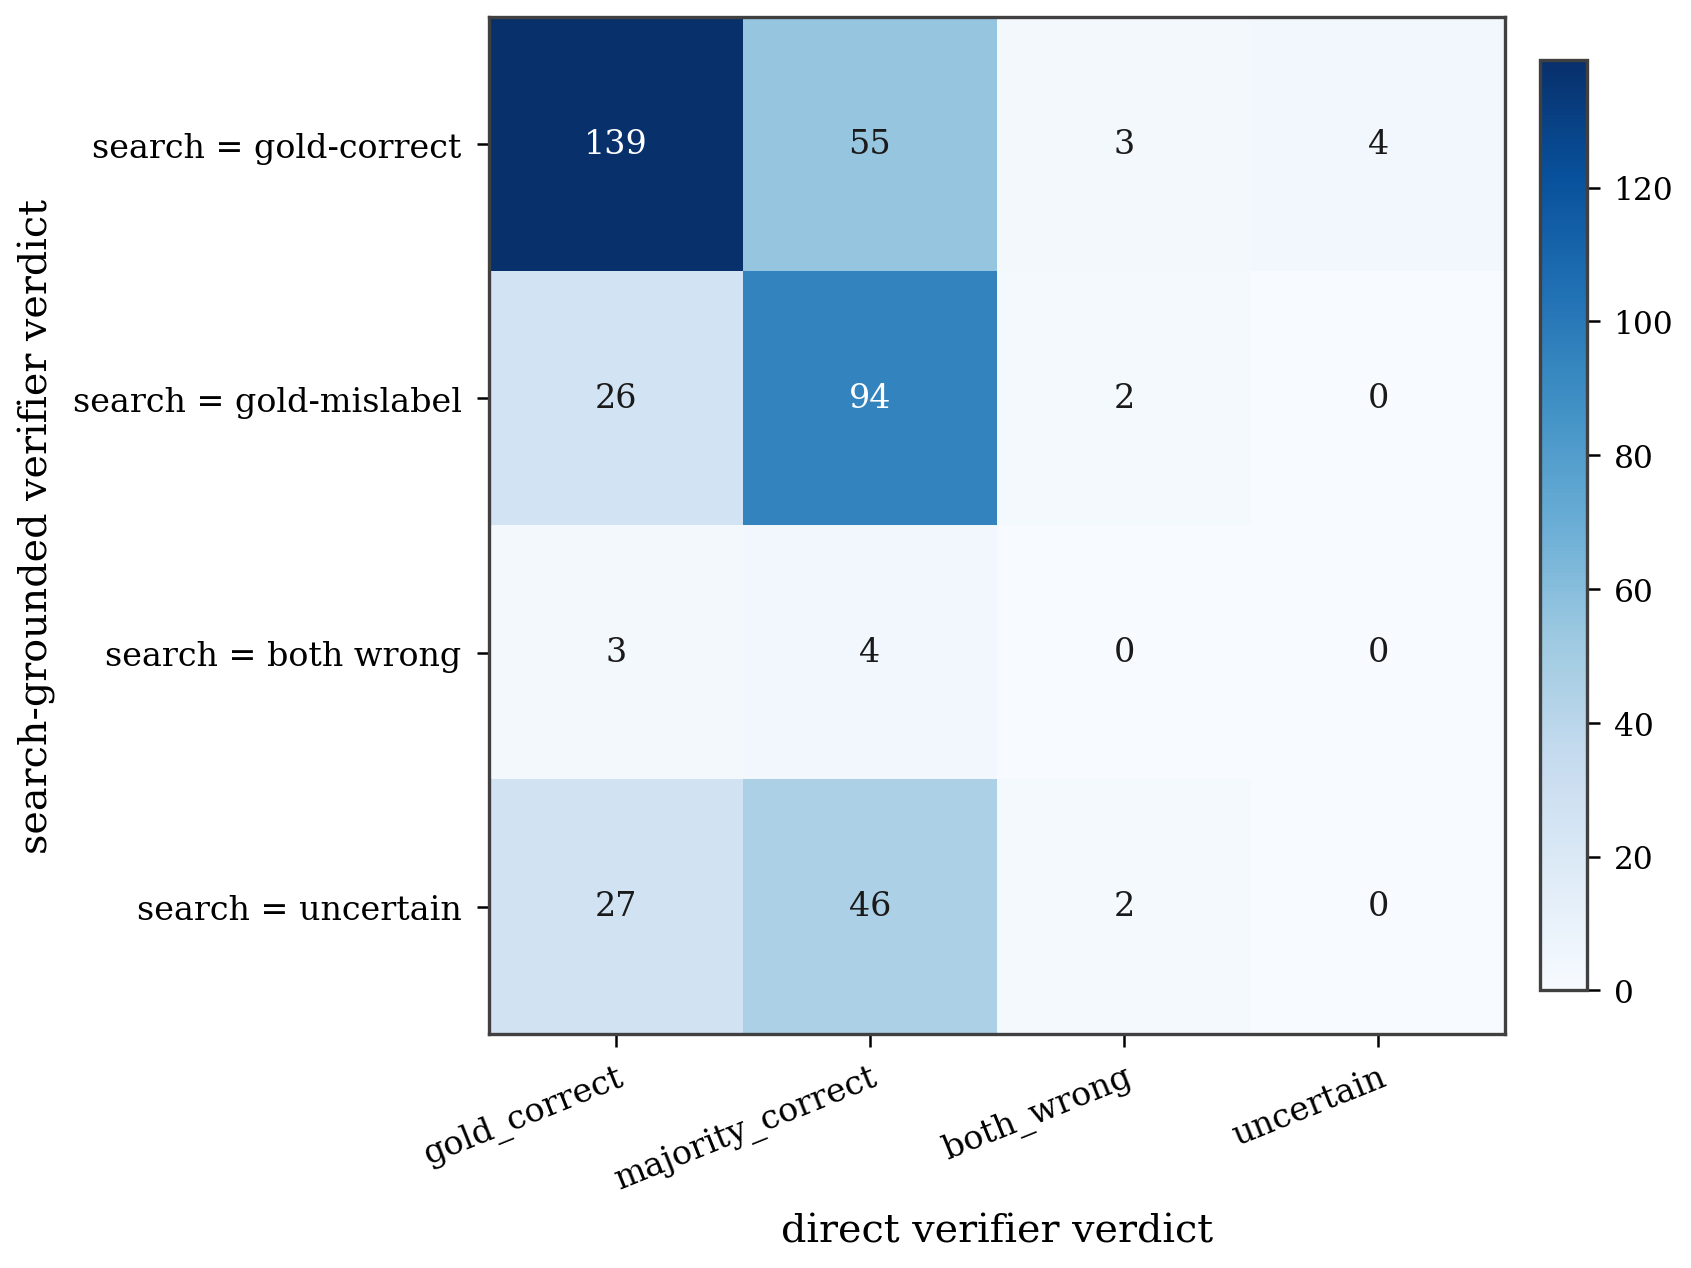

In [4]:
show_fig("agent_agreement.png")

_Supports the judge-reliability discussion ($\\mathcal{F}(\\mathcal{E})$)._

### Judge independence — a second, different-family judge

The pinned judge (GPT-5.4) is also one of the ten evaluated models, so its
verdicts could in principle favor its own family. We re-graded every stored
output with an independent judge (Claude Sonnet 4.6) and compared verdicts, and
additionally stressed the judge on the two strata where it can fail: calls it
returned `NONE`, and MCQ-family calls where its verdict differs from a
deterministic regex (`analysis.judge_adversarial`).


In [5]:
import json, pandas as pd
from IPython.display import display
s = json.loads((REPORTS_DIR / "judge_adversarial/summary.json").read_text())
m = s["machine_second_rater_gpt_vs_claude"]
display(pd.DataFrame([
    {"stratum": k, "n": v["n"], "agreement_%": v["agreement_pct"], "cohens_kappa": v["cohens_kappa"]}
    for k, v in m.items()
]))
print("adversarial strata sizes:", s["strata_sizes"])

,stratum,n,agreement_%,cohens_kappa
0,FULL,437066,99.59,0.9886
1,NONE,1623,94.58,0.0000
2,DISAGREE,50461,98.13,0.8303
3,ADVERSARIAL,52079,98.02,0.8753


adversarial strata sizes: {'NONE': 1733, 'DISAGREE': 50456}


The two independent judges agree **99.6%** on the full set (κ≈0.99) and ~98% even
on the adversarial strata; GPT-5.4 gains only +0.22 pp from its own-family judge,
and the leaderboard is unchanged (Spearman ρ≈0.98). Two human annotators then
adjudicated a 120-item adversarial sample.


In [6]:
import pandas as pd
adv = pd.read_csv(REPORTS_DIR / "judge_adversarial/adversarial_sheet.csv")
print("adversarial items:", len(adv), " strata:", adv["stratum"].value_counts().to_dict())
if {"annotator_A", "annotator_B"}.issubset(adv.columns):
    both = adv[(adv["annotator_A"].astype(str).str.strip() != "") &
               (adv["annotator_B"].astype(str).str.strip() != "")]
    if len(both):
        print(f"human-annotated: {len(both)}/{len(adv)}  raw agreement: "
              f"{(both['annotator_A'] == both['annotator_B']).mean():.3f}")
    adj = adv.get("adjudicated")
    if adj is not None:
        adj = adj.astype(str).str.strip(); adj = adj[adj != ""]
        if len(adj):
            print(f"adjudicated judge accuracy: {(adj == 'judge_correct').sum()}/{len(adj)}")

adversarial items: 120  strata: {'NONE': 60, 'DISAGREE': 60}
human-annotated: 120/120  raw agreement: 0.992
adjudicated judge accuracy: 113/120


_Judge-independence and adversarial-reliability evidence (paper App.~B.5)._